<a href="https://colab.research.google.com/github/rujal2004/Money-Control-Clone-/blob/main/SalesPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
zfrom google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

 16305822389043184174122816592194.jpg
'231030137 (1).pdf'
 231030137.pdf
'231032009 (1).pdf'
'231032009. j11.1.pdf'
'231032009 j11.pdf'
 231032009.pdf
'Adobe Scan 06-Oct-2023.pdf'
'Adobe Scan 22-Aug-2023 (1).pdf'
'Adobe Scan 22-Aug-2023.pdf'
'Adobe Scan 29-Aug-2023.pdf'
 arihantchemistryjee.pdf
 certificate.pdf
 chemistry12.pdf
'chemistry (1).pdf'
'chemistry (2).pdf'
 chemistry.pdf
 Classroom
'Colab Notebooks'
 c++.pdf
'c programming.pdf'
'cs 25.pdf'
'cs 4 (1).pdf'
'cs 4 (2).pdf'
'cs 4.pdf'
'cs assignment 5 (1).pdf'
'cs assignment 5.pdf'
'data simulation pppp.pdf'
 DevTyagi_Resume.gdoc
 DOC-20230814-WA0008..gdoc
 DOC-20230814-WA0008..pdf
 documents.pdf
 doubly_LL.c
 English.pdf
 IMG-20240513-WA0100.jpg
'L 3 Self Exploration v3.ppt'
 leetc.docx
 leet.docx
'linear programming.pdf'
 maths2.pdf
 maths.pdf
 matrices.pdf
'nit Hamirpur 12 (1).pdf'
'nit Hamirpur 12.pdf'
 nithamirpur.pdf
 online_retail_II.csv
'personal documents.pdf'
 physical.pdf
'physics 89.pdf'
 physicspaper.pdf
 physics.pdf

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/online_retail_II.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [ ]:
# Quantity <= 0
invalid_quantity = (df['Quantity'] <= 0).sum()
print("Number of invalid quantity rows:", invalid_quantity)

# Price <= 0
invalid_price = (df['Price'] <= 0).sum()
print("Number of invalid price rows:", invalid_price)


Number of invalid quantity rows: 22950
Number of invalid price rows: 6207


In [ ]:
total_rows = len(df)
invalid_quantity_percent = (22950 / total_rows) * 100
invalid_price_percent = (6207 / total_rows) * 100

print(f"Invalid Quantity: {invalid_quantity_percent:.2f}%")
print(f"Invalid Price: {invalid_price_percent:.2f}%")


Invalid Quantity: 2.15%
Invalid Price: 0.58%


float64
Total rows: 1067371
Missing Customer ID rows: 243007
Percentage missing: 22.77%


/tmp/ipython-input-4288729205.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Customer ID'].fillna('unknown', inplace=True)
/tmp/ipython-input-4288729205.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['Customer ID'].fillna('unknown', inplace=True)


0
object
Percentage missing: 0.00%
Before: (1067371, 8)
After: (1044421, 8)
count    1.044421e+06
mean     1.117612e+01
std      1.294560e+02
min      1.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      8.099500e+04
Name: Quantity, dtype: float64


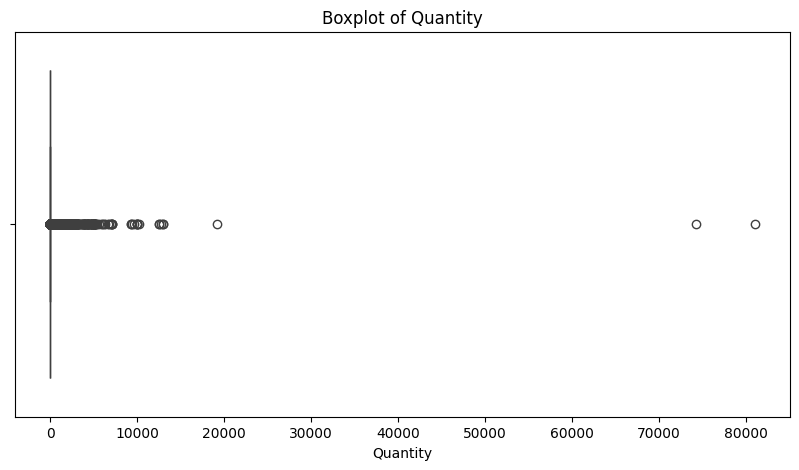

Lower bound: -3.0700000000000003
Upper bound: 8.45
count    1.044421e+06
mean     4.380607e+00
std      3.108216e+00
min      1.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      8.450000e+00
max      8.450000e+00
Name: Quantity, dtype: float64
Total rows: 1044421
Missing Price rows: 0
Percentage missing: 0.0 %
Invalid Price rows: 2750
Price_missing_flag
0    1041671
1       2750
Name: count, dtype: int64
                        count      mean       std  min  25%  50%   75%   max
Price_missing_flag                                                          
0                   1041671.0  4.379965  3.107601  1.0  1.0  3.0  8.45  8.45
1                      2750.0  4.623636  3.324680  1.0  1.0  4.0  8.45  8.45


/tmp/ipython-input-4288729205.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-3.0700000000000003' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Quantity'] < lower_bound, 'Quantity'] = lower_bound


Price_missing_flag
0    1041671
1       2750
Name: Customer ID, dtype: int64
End of distribution imputation done. Upper bound used: 8.45


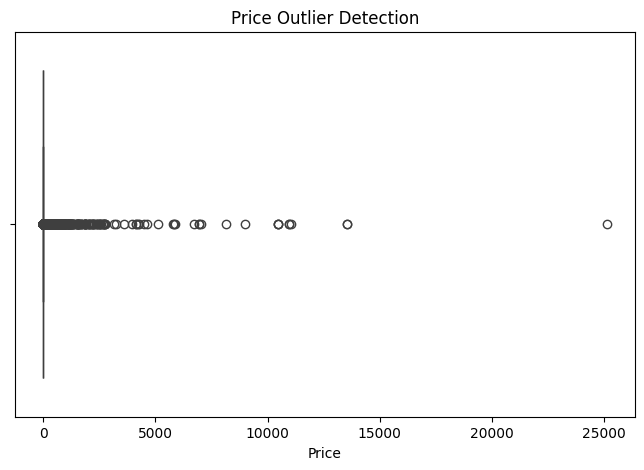

Lower bound: -3.1000000000000005
Upper bound: 8.5
count    1.044421e+06
mean     3.022293e+00
std      2.427077e+00
min      1.000000e-03
25%      1.250000e+00
50%      2.100000e+00
75%      4.150000e+00
max      8.500000e+00
Name: Price, dtype: float64


In [ ]:
print(df['Customer ID'].dtype)
# Total rows
total_rows = len(df)

# Missing Customer ID rows
missing_customer = df['Customer ID'].isnull().sum()

# Percentage of missing
missing_percentage = (missing_customer / total_rows) * 100

print(f"Total rows: {total_rows}")
print(f"Missing Customer ID rows: {missing_customer}")
print(f"Percentage missing: {missing_percentage:.2f}%")

# as 22.77% data is missing i am using arbitrary value imputation here

df['Customer ID'].fillna('unknown', inplace=True)

df['Customer ID'] = df['Customer ID'].astype(str)

## verifying

print(df['Customer ID'].isnull().sum())
print(df['Customer ID'].dtype)

# Check for missing values in Quantity
missing_quantity = df['Quantity'].isnull().sum()
total_rows = len(df)
missing_percentage = (missing_quantity / total_rows) * 100

print(f"Percentage missing: {missing_percentage:.2f}%")

# Size before removing zero/negative Quantity
print("Before:", df.shape)

# Now i will have those rows that have quantity more than zero
df = df[df['Quantity'] > 0]

# Size after removal
print("After:", df.shape)

print(df['Quantity'].describe())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(x=df['Quantity'])
plt.title('Boxplot of Quantity')
plt.show()

##here used capping because  we are prdicting sales analaysis

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

#Save outliers separately BEFORE capping
quantity_outliers = df[(df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound)]


df.loc[df['Quantity'] < lower_bound, 'Quantity'] = lower_bound
df.loc[df['Quantity'] > upper_bound, 'Quantity'] = upper_bound


print(df['Quantity'].describe())


## Now data preprocesing in price

# Total rows
total_rows = len(df)

# Missing values in Price
missing_price = df['Price'].isnull().sum()

# Percentage missing
missing_percentage = (missing_price / total_rows) * 100

print("Total rows:", total_rows)
print("Missing Price rows:", missing_price)
print("Percentage missing:", round(missing_percentage, 2), "%")

invalid_prices = df[df['Price'] <= 0]
print("Invalid Price rows:", len(invalid_prices))
# Create flag: 1 if Price <= 0, else 0
df['Price_missing_flag'] = (df['Price'] <= 0).astype(int)

# Quick check
print(df['Price_missing_flag'].value_counts())

# Compare with Quantity
print(df.groupby('Price_missing_flag')['Quantity'].describe())

# Compare with Customer ID
print(df.groupby('Price_missing_flag')['Customer ID'].count())


Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df.loc[df['Price'] <= 0, 'Price'] = upper_bound
print("End of distribution imputation done. Upper bound used:", upper_bound)

## Checking Outliers

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Price'])
plt.title("Price Outlier Detection")
plt.show()


Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

#Save outliers separately BEFORE capping

Price_outliers = df[(df['Price'] < lower_bound) | (df['Price'])]

df.loc[df['Price'] < lower_bound, 'Price'] = lower_bound
df.loc[df['Price'] > upper_bound, 'Price'] = upper_bound


print(df['Price'].describe())

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Weekday'] = df['InvoiceDate'].dt.weekday
df['Week'] = df['InvoiceDate'].dt.isocalendar().week
df['Hour'] = df['InvoiceDate'].dt.hour
## Adding a Revenue Column
df['Revenue'] = df['Quantity'] * df['Price']


In [ ]:
categorical_cols = ['StockCode', 'Country', 'Customer ID']
numeric_cols = ['Year', 'Month', 'DayOfWeek', 'Hour']

X = df[categorical_cols + numeric_cols].copy()
y = df['Sales']


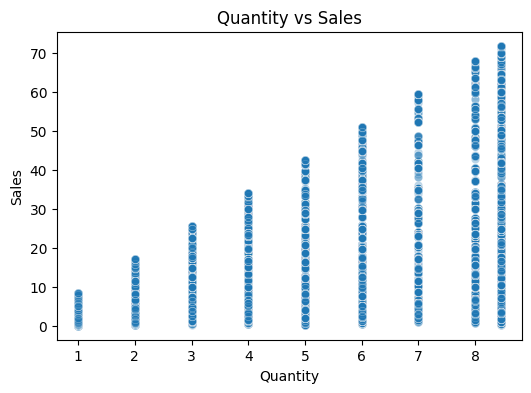

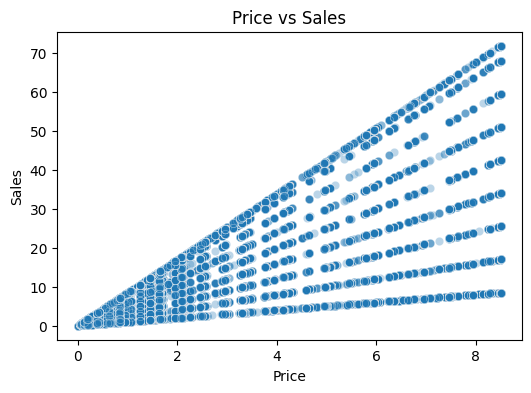

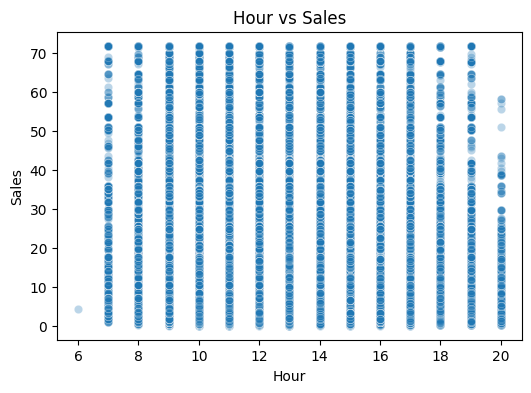

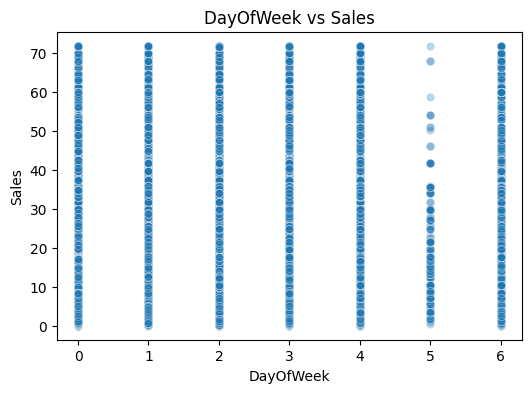

In [ ]:
numeric_cols = ['Quantity', 'Price', 'Hour', 'DayOfWeek']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['Sales'], alpha=0.3)
    plt.title(f"{col} vs Sales")
    plt.show()


In [ ]:
for col in categorical_cols:
    X[col] = X[col].fillna('unknown').astype(str)  # convert to string
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)


KeyboardInterrupt: 

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=50,      # fewer trees
    max_depth=10,         # limit tree depth
    max_features="sqrt",  # use subset of features
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, max_features='sqrt', n_estimators=50,
                      n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance:")
print(f"MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}, R²: {rf_r2:.2f}")


Random Forest Performance:
MAE: 6.09, RMSE: 9.29, R²: 0.13


In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in ['StockCode', 'Country']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------
# Step 1: Prepare Data
# ---------------------------
df['Sales'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Time features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

# Fill missing Customer ID
df['Customer ID'] = df['Customer ID'].fillna(-1)

# ---------------------------
# Step 2: Select features
# ---------------------------
categorical_cols = ['StockCode', 'Country', 'Customer ID']
numeric_cols = ['Year', 'Month', 'DayOfWeek', 'Hour']

X = df[categorical_cols + numeric_cols].copy()
y = df['Sales']

# ---------------------------
# Step 3: Encode all categorical features
# ---------------------------
for col in categorical_cols:
    X[col] = X[col].fillna('unknown').astype(str)
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# ---------------------------
# Step 4: Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# Step 5: Train Gradient Boosting
# ---------------------------
gb_model = GradientBoostingRegressor(
    n_estimators=100,   # fewer boosting stages
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Predict
gb_pred = gb_model.predict(X_test)

# ---------------------------
# Step 6: Evaluate
# ---------------------------
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Performance:")
print(f"MAE: {gb_mae:.2f}, RMSE: {gb_rmse:.2f}, R²: {gb_r2:.2f}")


Gradient Boosting Performance:
MAE: 5.97, RMSE: 9.14, R²: 0.16


In [ ]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,  # no limit
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)
lgbm_pred = lgbm_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("LightGBM Performance:")
print(f"MAE: {mean_absolute_error(y_test, lgbm_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lgbm_pred)):.2f}")
print(f"R²: {r2_score(y_test, lgbm_pred):.2f}")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 591
[LightGBM] [Info] Number of data points in the train set: 835536, number of used features: 7
[LightGBM] [Info] Start training from score 10.217421
LightGBM Performance:
MAE: 5.48
RMSE: 8.57
R²: 0.26


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("LightGBM Performance:")
print(f"MAE: {mean_absolute_error(y_test, lgbm_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lgbm_pred)):.2f}")
print(f"R²: {r2_score(y_test, lgbm_pred):.2f}")


LightGBM Performance:
MAE: 5.48
RMSE: 8.57
R²: 0.26


In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

cat_features_idx = [X.columns.get_loc(col) for col in categorical_cols]

cat_model = CatBoostRegressor(
    iterations=200,       # number of trees
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=100           # prints progress
)

cat_model.fit(
    X_train, y_train,
    cat_features=cat_features_idx
)

# ---------------------------
# Step 5: Predict & Evaluate
# ---------------------------
cat_pred = cat_model.predict(X_test)

# If log-transform was used, invert it
# cat_pred = np.expm1(cat_pred)

cat_mae = mean_absolute_error(y_test, cat_pred)
cat_rmse = np.sqrt(mean_squared_error(y_test, cat_pred))
cat_r2 = r2_score(y_test, cat_pred)

print("CatBoost Performance:")
print(f"MAE: {cat_mae:.2f}")
print(f"RMSE: {cat_rmse:.2f}")
print(f"R²: {cat_r2:.2f}")

0:	learn: 9.5424038	total: 1.29s	remaining: 4m 16s
100:	learn: 7.3495574	total: 55.2s	remaining: 54.1s
199:	learn: 7.2569686	total: 1m 42s	remaining: 0us
CatBoost Performance:
MAE: 4.24
RMSE: 7.16
R²: 0.48


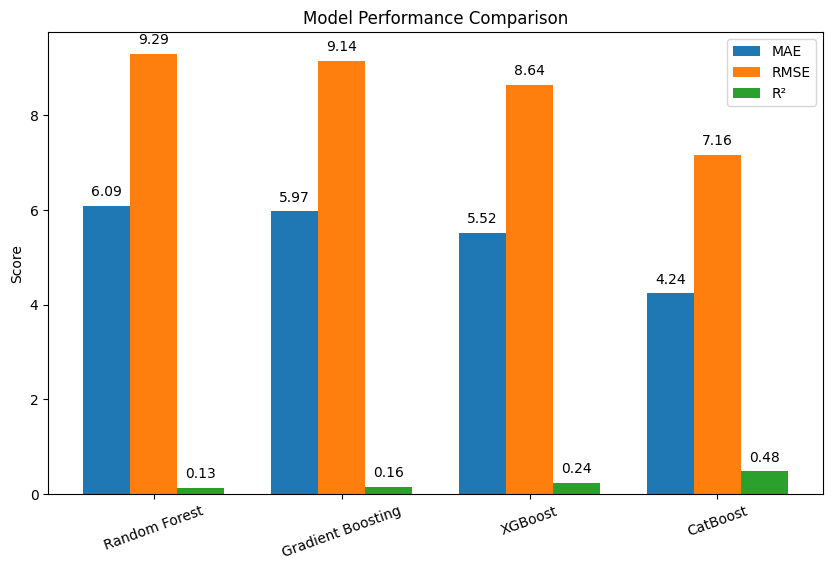

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ["Random Forest", "Gradient Boosting", "XGBoost", "CatBoost"]

# Metrics from your results
mae = [6.09, 5.97, 5.52, 4.24]
rmse = [9.29, 9.14, 8.64, 7.16]
r2 = [0.13, 0.16, 0.24, 0.48]

x = np.arange(len(models))  # label locations
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(10,6))

# Plotting bars side by side
rects1 = ax.bar(x - width, mae, width, label="MAE")
rects2 = ax.bar(x, rmse, width, label="RMSE")
rects3 = ax.bar(x + width, r2, width, label="R²")

# Labels & formatting
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.legend()

# Add values on top of bars
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()
